In [ ]:
from utils import add_project_root_to_sys_path
add_project_root_to_sys_path()
from neuralnet.datasets import ParquetDataset
from neuralnet.datasets.ringer import RingerParquetDataset
from neuralnet.plotting import plot_variable_distribution_comparison
from neuralnet.workflows.mlp.training import MLPKerasTrainingJob
from pathlib import Path
import matplotlib.pyplot as plt
import mplhep as hep
plt.style.use(hep.style.ATLAS)
import polars as pl
import numpy as np
from itertools import product

In [2]:
dataset_dir = Path.home() /"data" / "ringer-datasets" / "datasets" / "mc21_isabela_qt_2sigma_restriction"
dataset = ParquetDataset(dataset_dir=dataset_dir)
dataset

ParquetDataset(dataset_dir=PosixPath('/home/lucasbanunes/data/ringer-datasets/datasets/mc21_isabela_qt_2sigma_restriction'))

In [ ]:
fp_model_training_job_path = Path.home() / 'data' / 'neuralnet_jobs' / 'mlp'
training_job = MLPKerasTrainingJob.load(fp_model_training_job_path)
fp_inference_pipeline = training_job.get_inference_pipeline(
    et_col="TrigEMClusterContainer.et",
    eta_col="TrigEMClusterContainer.eta",
    rings_col="TrigEMClusterContainer.ringsE"
)
ptq_inference_pipeline = fp_inference_pipeline.fixed_point_quantization(
    norm_quantizer=dict(integer_bits=32, fractional_bits=32),
    weight_quantizer=dict(i0=32, f0=32),
    bias_quantizer=dict(i0=32, f0=32),
)

In [ ]:
# data_df = (
#     dataset.get_dataframe('electron_ringer')
#     .select('id', *fp_inference_pipeline.input_cols)
#     .collect()
# )
# data_df
mlp

id,TrigEMClusterContainer.ringsE,TrigEMClusterContainer.eta,TrigEMClusterContainer.et
u64,list[f32],f32,f32
4344867,"[0.0, 0.0, … 0.0]",-2.314113,8687.142578
4345705,"[210.372803, 210.660446, … 0.0]",1.15182,9140.586914
4345973,"[0.0, 0.0, … 0.0]",-2.273792,23412.291016
4347370,"[484.365326, 1406.85083, … 0.0]",-0.622368,12100.351562
4347541,"[0.0, 0.0, … 0.0]",2.125269,8970.791992
…,…,…,…
101996,"[1138.499146, 582.537537, … 0.0]",-0.822559,12097.719727
110253,"[799.319519, 561.031799, … 0.0]",-0.774715,7735.183594
109773,"[0.0, 0.0, … 0.0]",2.204386,18209.179688


In [8]:
fp_df = fp_inference_pipeline(data_df, batch_size=4096)
fp_df

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


 [Sun, 05 Jul 2026 15:33:13] WARNING 5 out of the last 62 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x7696ac15fec0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.


1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step

 [Sun, 05 Jul 2026 15:33:13] WARNING 6 out of the last 63 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x7696ac15fec0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


id,output
u64,f32
5210028,0.994293
5327969,0.287709
5333618,0.970516
5394766,0.941282
5501896,0.985296
…,…
7217760,0.995028
7242863,0.979023
7243005,0.85724


In [9]:
ptq_df = ptq_inference_pipeline(data_df, batch_size=4096)
ptq_df

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 262ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


id,output
u64,f32
5210028,0.999806
5327969,0.247457
5333618,0.994956
5394766,0.779545
5501896,0.999992
…,…
7217760,0.019625
7242863,0.019625
7243005,0.956092


In [10]:
analysis_df = (
    data_df
    .join(fp_df.rename(lambda col: f'fp.{col}' if col != 'id' else col), on='id')
    .join(ptq_df.rename(lambda col: f'ptq.{col}' if col != 'id' else col), on='id')
)
analysis_df

id,TrigEMClusterContainer.ringsE,TrigEMClusterContainer.eta,TrigEMClusterContainer.et,fp.output,ptq.output
u64,list[f32],f32,f32,f32,f32
5210028,"[13134.181641, 6102.278809, … 0.0]",1.440676,47825.5,0.994293,0.999806
5327969,"[2803.400879, 10593.138672, … 0.0]",-1.484016,40253.039062,0.287709,0.247457
5333618,"[5546.027344, 1767.633179, … 0.0]",1.387818,41948.800781,0.970516,0.994956
5394766,"[3954.7854, 3199.468506, … 0.0]",-1.441384,45269.539062,0.941282,0.779545
5501896,"[5769.23291, 5650.573242, … 0.0]",-1.438865,44986.140625,0.985296,0.999992
…,…,…,…,…,…
7217760,"[1960.620239, 828.605164, … 0.0]",0.99946,38109.160156,0.995028,0.019625
7242863,"[2288.791992, 421.71933, … 0.0]",1.293913,39566.871094,0.979023,0.019625
7243005,"[1269.585083, 1596.784424, … 0.0]",-1.019143,39864.925781,0.85724,0.956092


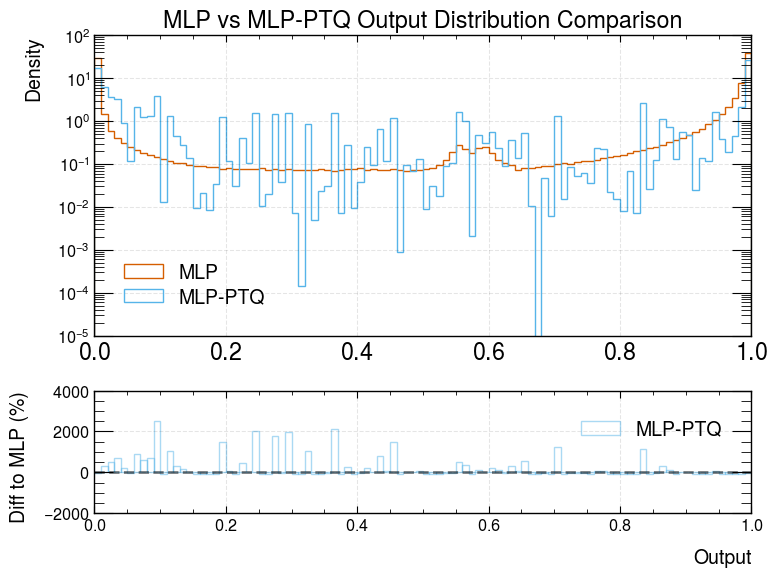

In [12]:
fig, _, _ = plot_variable_distribution_comparison(
    variable_label='Output',
    ref={'name': 'fp.output', 'label': 'MLP', 'color': 'C0'},
    to_compare=[
        {'name': 'ptq.output', 'label': 'MLP-PTQ', 'color': 'C1'},
    ],
    data=analysis_df,
    title='MLP vs MLP-PTQ Output Distribution Comparison',
    scale='log',
    hist_kwargs=dict(bins=100)
)
fig.tight_layout()

In [ ]:
percentiles = [
    0.25,
    -0.25,
    0.1,
    -0.9,
]
abs_percentiles = set(np.abs(percentiles))
percentiles_expressions = [
    pl.col(col_name).quantile(percentile) for col_name, percentile in product(abs_percentiles, ['fp.output', 'ptq.output'])
]
for percentile in percentiles:
    percentile_value = analysis_df.select(f'ptq.output').quantile(percentile).collect()[0, 0]
    fig, _, _ = plot_variable_distribution_comparison(
        variable_label='Output',
        ref={'name': 'fp.output', 'label': 'MLP', 'color': 'C0'},
        to_compare=[
            {'name': 'ptq.output', 'label': 'MLP-PTQ', 'color': 'C1'},
        ],
        data=analysis_df.filter(pl.col('ptq.output') <= percentile_value),
        title=f'MLP vs MLP-PTQ Output Distribution Comparison (ptq.output <= {percentile_value:.4f})',
        scale='log',
        hist_kwargs=dict(bins=100)
    )
    fig.tight_layout()